# `preion.theory` tutorial

Reionisation observables from the electron power spectrum, computed with a
single consistent physical model (`Pee_model`): the kSZ angular power
spectrum, the optical depth (tau-tau) power spectrum, the 21cm power
spectrum, and the reionisation B-modes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import cosmology
import time
from matplotlib import colors, colormaps

from preion.theory import Pee_model

%matplotlib inline

In [2]:
def f(ell):
    """To plot l(l+1)/2pi CMB spectra """
    return ell*(ell+1)/2/np.pi

## Building a model

`Pee_model` takes the reionisation history (`zre_h`, `dz_h`) and morphology
(`alpha0`, `kappa`) parameters, plus a cosmological model, to compute the kSZ angular power spectrum, the optical depth power spectrum, and the 21cm power spectrum. All observables are derived from a consistent model, based on the electron power spectrum parameterisation introduced in Gorce et. al 2020. 

If `run_camb=True`, the class runs CAMB once
so all the observables below share the same primary CMB spectra and matter
power spectrum.

In [3]:
cos = cosmology.Planck18

In [4]:
t0 = time.time()
preion_model = Pee_model(
    zre_h=7.0, dz_h=1.5, alpha0=3.7, kappa=0.10,
    h=cos.h, Ob_0=cos.Ob0, Om_0=cos.Om0,
    verbose=True, run_camb=True,
) # takes ~2min to initilialise (initial CAMB run)
t1 = time.time()
print(f'Model initialisation took {(t1-t0):.2f} seconds.')

zre_h = 7.0, zend = 5.5
Late-time ionisation fraction: 1.16
tau = 0.0534
Running CAMB...
Model initialisation took 164.41 seconds.


Text(0.5, 1.0, '$z=7.0$')

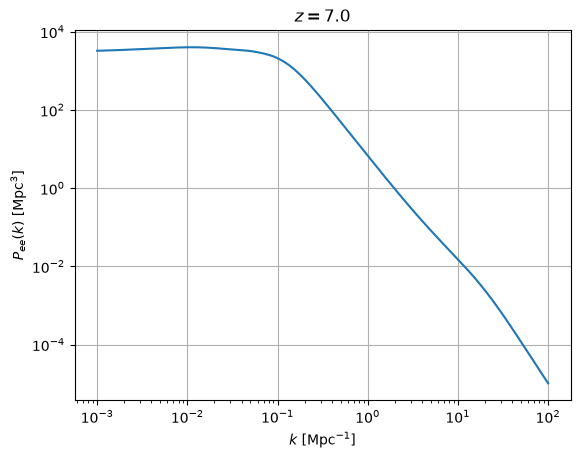

In [5]:
klog = np.logspace(-3, 2, 500)

plt.figure()
plt.loglog(klog, preion_model.Pee(klog, preion_model.zre_h))
plt.xlabel(r'$k$ [Mpc$^{-1}$]')
plt.ylabel(r'$P_{ee}(k)$ [Mpc$^3$]')
plt.grid()
plt.title(rf'$z={preion_model.zre_h:.1f}$')

### Reionisation history

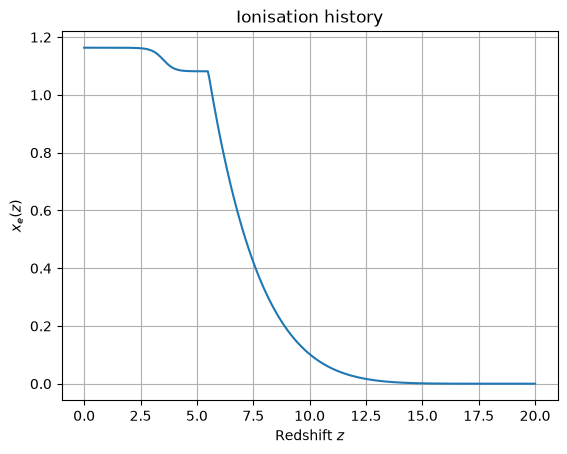

In [6]:
z = np.linspace(0, 20, 300)
xe = preion_model.xe(z)

plt.figure()
plt.plot(z, xe)
plt.xlabel('Redshift $z$')
plt.ylabel('$x_e(z)$')
plt.title('Ionisation history')
plt.grid()

0.05337984560807985


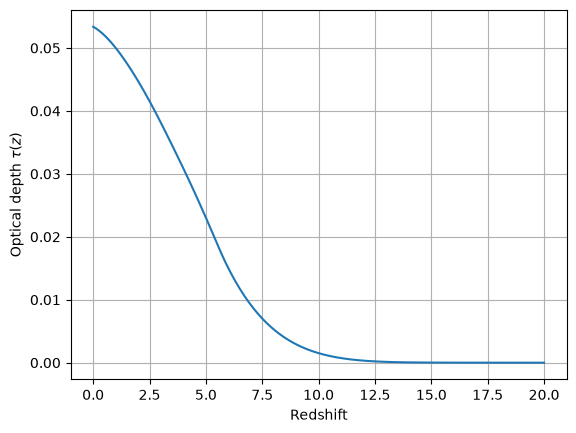

In [7]:
plt.figure()
plt.plot(z, preion_model.xe2tau(z))
plt.xlabel(r'Redshift')
plt.ylabel(r'Optical depth $\tau(z)$')
plt.grid()
print(preion_model.xe2tau(z)[0])

### Primary CMB power spectra

The class also computes primary power spectra:

In [8]:
ells = np.arange(50, 4000, step=50)
CMB_Dells = preion_model.get_primary_spectra(ells=ells, Dells=True)

 Computing CMB power spectra...


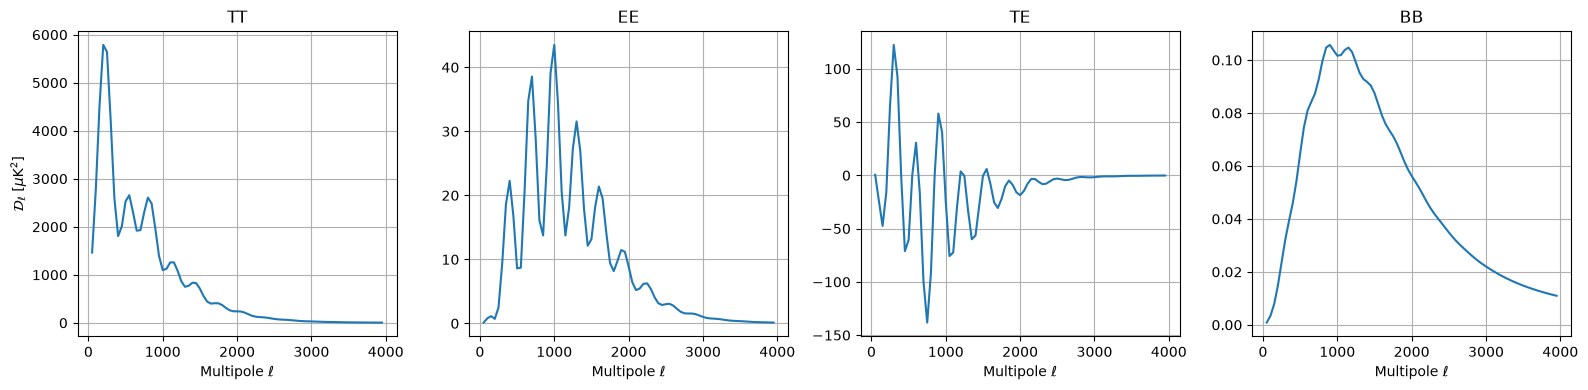

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, i, title in zip(axes, range(4), ['TT', 'EE', 'TE', 'BB']):
    ax.plot(ells, CMB_Dells[:, i+1])
    ax.set_title(title)
    ax.set_xlabel(r'Multipole $\ell$')
    ax.grid()
axes[0].set_ylabel(r'$\mathcal{D}_\ell$ [$\mu$K$^2$]')
fig.tight_layout()
plt.show()

### kSZ power spectrum

To compute the kSZ power spectrum, use the `get_ksz` method. 
The following will output the kSZ power on a range of multipoles `ells` as $\mathcal{D}_\ell = T_\mathrm{CMB} \ell (\ell + 1) C_\ell / 2 \pi$.

In [10]:
ells_ksz = np.arange(1000, 5000, step=250)

t0 = time.time()
ksz_ps = preion_model.get_ksz(ells=ells_ksz, signal='both', Dells=True)
t1 = time.time()
print(f'Computation took {t1-t0:.1f} seconds.')

Computation took 43.6 seconds.


In [11]:
i3000 = np.argmin(np.abs(3000-ells_ksz))
print(f'At l=3000, patchy power = {ksz_ps[i3000, 0]:.1f} uK2, late-time power = {ksz_ps[i3000, 1]:.1f} uK2')

At l=3000, patchy power = 1.2 uK2, late-time power = 3.2 uK2


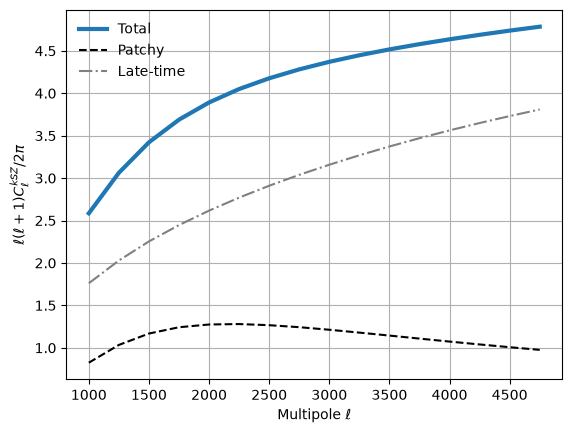

In [12]:
plt.figure()
plt.plot(ells_ksz, np.sum(ksz_ps, axis=1), label='Total', lw=3.)
plt.plot(ells_ksz, ksz_ps[:, 0], label='Patchy', ls='--', color='k')
plt.plot(ells_ksz, ksz_ps[:, 1], label='Late-time', ls='-.', color='grey')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\ell(\ell+1)C_\ell^{kSZ}/2\pi$')
plt.grid()
plt.legend(frameon=False)

### Tau-tau power spectrum

To compute the $\tau-\tau$ power spectrum, use the `get_tau` method. 
The following will output the tau power on a range of multipoles `ells` as $\mathcal{D}_\ell = T_\mathrm{CMB} \ell (\ell + 1) C_\ell / 2 \pi$.

In [13]:
ells_tau = np.arange(50, 10000, step=250)
tau_ps = preion_model.get_tau(ells=ells_tau, signal='both', Dells=True)

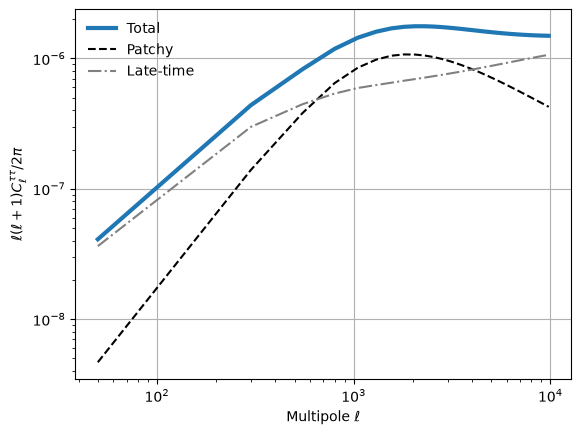

In [14]:
plt.figure()
plt.loglog(ells_tau, np.sum(tau_ps, axis=1), label='Total', lw=3.)
plt.plot(ells_tau, tau_ps[:, 0], label='Patchy', ls='--', color='k')
plt.plot(ells_tau, tau_ps[:, 1], label='Late-time', ls='-.', color='grey')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\ell(\ell+1)C_\ell^{\tau\tau}/2\pi$')
plt.legend(frameon=False)
plt.grid()

### 21cm power spectrum

`get_p21(k, z)` gives the 21cm power spectrum at a fixed redshift; here we
show it at a handful of redshifts spanning reionisation.

In [15]:
zarr = np.linspace(5., 10, 20)
karr = np.logspace(-3, 1, 100)

ps_21 = preion_model.get_p21(karr, zarr[:, None], mK=True, log=False, pk_units=True)

Text(0, 0.5, 'Reionisation history')

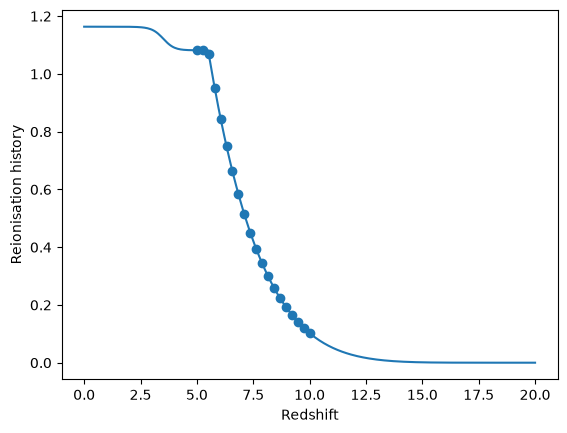

In [16]:
z = np.linspace(0, 20, 300)

plt.figure()
plt.plot(z, preion_model.xe(z))
plt.scatter(zarr, preion_model.xe(zarr))
plt.xlabel(r'Redshift')
plt.ylabel(r'Reionisation history')

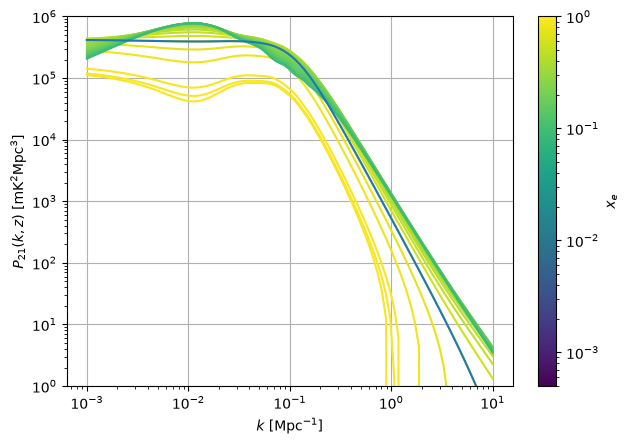

In [17]:
cmap = colormaps['viridis']
norm = colors.LogNorm(vmin=5e-4, vmax=1.)

fig, ax = plt.subplots()
ax.grid()
for iz, z in enumerate(zarr):
    ax.loglog(karr, ps_21[iz], color=cmap(norm(preion_model.xe(z)[0]/preion_model.f)))
ax.plot(karr, ps_21[5])
ax.set_ylim(1e0, 1e6)
ax.set_xlabel(r'$k$ [Mpc$^{-1}]$')
ax.set_ylabel(r'$P_{21}(k, z)$ [mK$^2$Mpc$^3]$')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
c_bar = plt.colorbar(sm, fraction=0.05, label=r'$x_e$', ax=ax)

### $B$-modes

Reionisation sources two types of $B$-modes: scattering (patchy + late-time
Thomson scattering off free electrons) and screening (attenuation of the
primary $E$-modes by patchy $\tau$). `get_B_modes` returns their sum.

In [18]:
low_ells = np.arange(1, 3000, step=20)

scattering_bb = preion_model.get_scattering_B_modes(ells=low_ells, signal='both', Dells=True)
screening_bb = preion_model.get_screening_B_modes(ells=low_ells, Dells=True)

 Computing CMB power spectra...


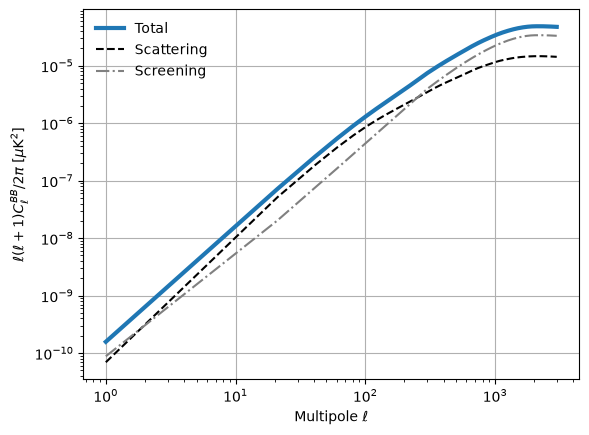

In [ ]:
plt.figure()
plt.loglog(low_ells, np.sum(scattering_bb, axis=1)+screening_bb, label='Total', lw=3.)
plt.plot(low_ells, np.sum(scattering_bb, axis=1), label='Scattering', ls='--', color='k')
plt.plot(low_ells, screening_bb, label='Screening', ls='-.', color='grey')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\ell(\ell+1)C_\ell^{BB}/2\pi$ [$\mu$K$^2$]')
plt.legend(frameon=False, loc='upper left')
plt.grid()